Berikut adalah langkah-langkah untuk mengambil data dari Twitter dan melakukan analisis sentimen terhadap topik Manchester City dari Januari hingga Desember 2023 menggunakan regresi logistik. Script ini menggunakan library Python seperti tweepy untuk mengambil data Twitter, TextBlob dan emoji untuk analisis sentimen termasuk emoji, serta scikit-learn untuk analisis regresi logistik.

**Langkah 1: Setup dan Install Library**

Pastikan Anda memiliki API Key untuk Twitter API. Install library yang dibutuhkan:

In [ ]:
pip install tweepy pandas scikit-learn textblob emoji nltk

**Langkah 2: Masuk ke twitter developer**

https://developer.x.com/en

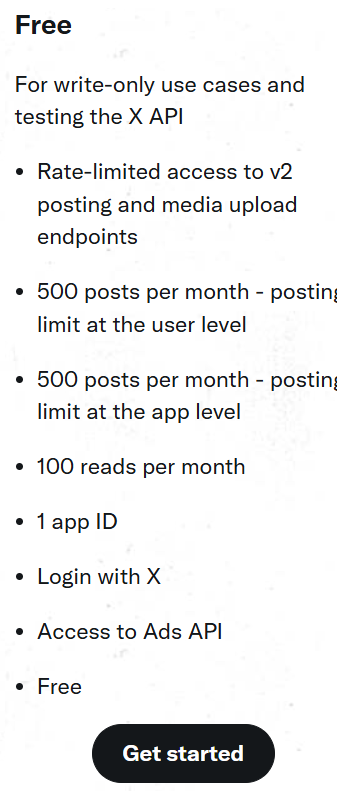

Masuk ke Get Started

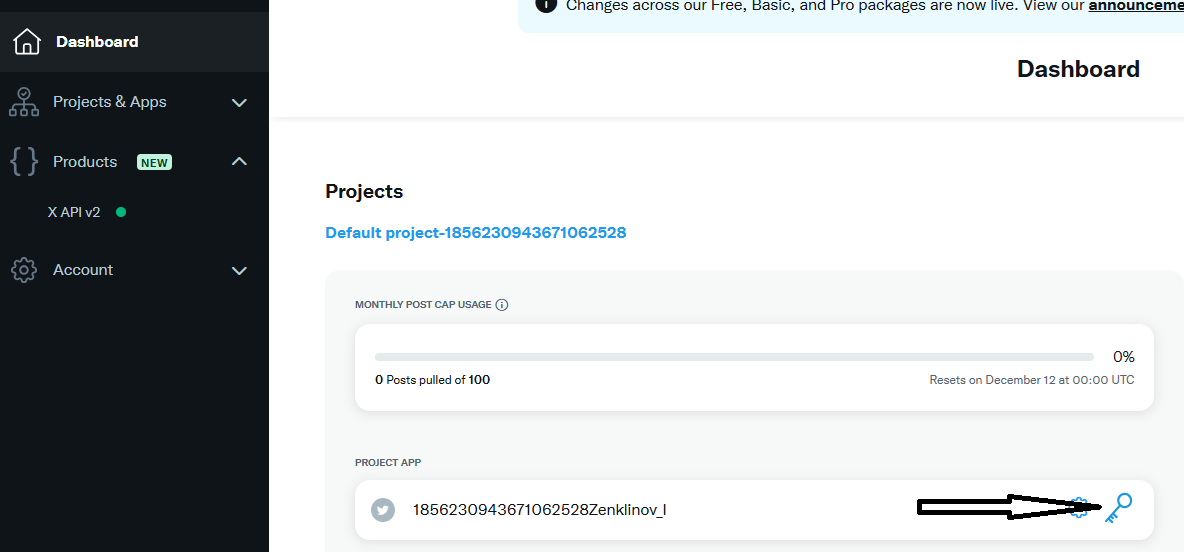

Pilih Key pada dashboard

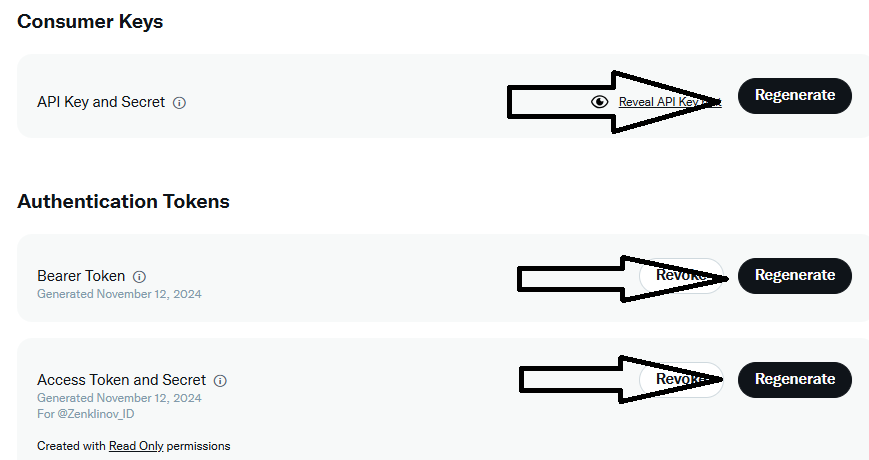

Lakukan Generate Semua token

**Langkah 3: Code Python**

In [ ]:
import tweepy
import pandas as pd
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import emoji
import nltk

# Download NLTK resources
nltk.download('punkt')

# Setup Twitter API credentials
API_KEY = 'your_api_key'
API_SECRET = 'your_api_secret'
ACCESS_TOKEN = 'your_access_token'
ACCESS_SECRET = 'your_access_secret'

# Authenticate to Twitter
auth = tweepy.OAuthHandler(API_KEY, API_SECRET)
auth.set_access_token(ACCESS_TOKEN, ACCESS_SECRET)
api = tweepy.API(auth, wait_on_rate_limit=True)

# Fetch tweets
def fetch_tweets(query, start_date, end_date, count=1000):
    tweets = []
    for tweet in tweepy.Cursor(api.search_tweets,
                               q=query,
                               lang="en",
                               since=start_date,
                               until=end_date,
                               tweet_mode='extended').items(count):
        tweets.append(tweet.full_text)
    return tweets

# Sentiment analysis function
def analyze_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

# Fetch tweets about Manchester City
tweets = fetch_tweets(query="Manchester City", start_date="2023-01-01", end_date="2023-12-31", count=2000)

# Create DataFrame
df = pd.DataFrame(tweets, columns=["tweet"])
df['emoji_count'] = df['tweet'].apply(lambda x: len([char for char in x if char in emoji.EMOJI_DATA]))
df['sentiment'] = df['tweet'].apply(analyze_sentiment)

# Prepare data for Logistic Regression
df = df[df['sentiment'] != 'neutral']  # Exclude neutral sentiments
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})  # Encode sentiment

# Split data
X = df['tweet']
y = df['label']
vectorizer = CountVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Save DataFrame to CSV
df.to_csv("manchester_city_sentiment_analysis.csv", index=False)


Revisi Kode Ini, sesuai kan dengan acuan Analisis Sentiment Menggunakan Regresi Logistik:

https://github.com/zenklinov/regression_logistic_-_sentiment_analysis_movie_data